# AI-Powered Telecom Customer Retention Platform

**Student:** Maurizio Pinto  
**Program:** Master's Degree in AI — Udacity / Woolf University  
**Date:** May 2026  

## Project Overview

This project integrates methods from three prior capstone projects into an end-to-end telecom customer retention system:

| Component | Prior Project | Methods |
|---|---|---|
| Statistical Analysis | Project 2 — Statistical Analysis | Chi-squared test, Welch's t-test, descriptive statistics |
| ML Churn Prediction | Project 3 — ML Model Design | Logistic Regression, Random Forest, feature importance |
| Agentic Retention Advisor | Project 6 — Agentic AI | ReAct loop, OpenAI function calling, safeguards |

**Pipeline flow:** Statistical Analysis → ML Prediction → Risk-Adjusted CLV → Agentic Retention Action

## Setup

In [1]:
import json
import os
import time
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)

from openai import OpenAI
from dotenv import load_dotenv

sns.set_theme(style='whitegrid')
%matplotlib inline
np.random.seed(42)

## Data Loading & Inspection

In [2]:
df = pd.read_csv('dataset/WA_Fn-UseC_-Telco-Customer-Churn.csv')
print(f'Dataset shape: {df.shape}')
print(f'Columns: {df.shape[1]}, Rows: {df.shape[0]}')
df.head()

Dataset shape: (7043, 21)
Columns: 21, Rows: 7043


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [4]:
print('Missing values:')
print(df.isnull().sum())
print(f'\nTotal missing: {df.isnull().sum().sum()}')

Missing values:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Total missing: 0


In [5]:
# Class distribution
churn_counts = df['Churn'].value_counts()
churn_pct = df['Churn'].value_counts(normalize=True) * 100
print('Churn distribution:')
print(f'  No Churn:  {churn_counts["No"]:,} ({churn_pct["No"]:.1f}%)')
print(f'  Churn:     {churn_counts["Yes"]:,} ({churn_pct["Yes"]:.1f}%)')
print(f'  Churn rate: {churn_pct["Yes"]:.1f}%')

Churn distribution:
  No Churn:  5,174 (73.5%)
  Churn:     1,869 (26.5%)
  Churn rate: 26.5%


## Statistical Analysis — Validating Churn Patterns

This component applies methods from **Project 2 (Statistical Analysis)** to validate that observed churn patterns are statistically significant. We use:

- **Chi-squared test of independence** to test whether contract type and churn are associated (appropriate because churn is binary and contract type is categorical with 3 levels)
- **Welch's t-test** to test whether MonthlyCharges differ significantly between churners and non-churners (same test pattern as Project 2, where we compared insurance charges between smokers and non-smokers)
- **Descriptive statistics** segmented by key customer attributes

These tests provide human-interpretable evidence that informs segment-level retention strategy — complementing the ML model's individual-level predictions.

In [6]:
# Chi-squared test: Contract type vs. Churn
contingency = pd.crosstab(df['Contract'], df['Churn'])
print('Contingency table (Contract type × Churn):')
print(contingency)
print()

chi2, p_value, dof, expected = stats.chi2_contingency(contingency)
print(f'Chi-squared test of independence:')
print(f'  χ² statistic = {chi2:.2f}')
print(f'  p-value      = {p_value:.2e}')
print(f'  degrees of freedom = {dof}')
print()

alpha = 0.05
if p_value < alpha:
    print(f'Result: REJECT H₀ (p = {p_value:.2e} < {alpha})')
    print('There IS a statistically significant association between contract type and churn.')
    print()
    churn_by_contract = df.groupby('Contract')['Churn'].apply(lambda x: (x == 'Yes').mean() * 100)
    print('Churn rates by contract type:')
    for contract, rate in churn_by_contract.items():
        print(f'  {contract:20s}: {rate:.1f}%')
else:
    print(f'Result: FAIL TO REJECT H₀ (p = {p_value:.2e} >= {alpha})')

Contingency table (Contract type × Churn):
Churn             No   Yes
Contract                  
Month-to-month  2220  1655
One year        1307   166
Two year        1647    48

Chi-squared test of independence:
  χ² statistic = 1184.60
  p-value      = 5.86e-258
  degrees of freedom = 2

Result: REJECT H₀ (p = 5.86e-258 < 0.05)
There IS a statistically significant association between contract type and churn.

Churn rates by contract type:
  Month-to-month      : 42.7%
  One year            : 11.3%
  Two year            : 2.8%


In [7]:
# Welch's t-test: MonthlyCharges by Churn group
charges_churn = df[df['Churn'] == 'Yes']['MonthlyCharges']
charges_no_churn = df[df['Churn'] == 'No']['MonthlyCharges']

print('MonthlyCharges by churn group:')
print(f'  Churners (n={len(charges_churn)}):    mean=${charges_churn.mean():.2f}, median=${charges_churn.median():.2f}, std=${charges_churn.std():.2f}')
print(f'  Non-churners (n={len(charges_no_churn)}): mean=${charges_no_churn.mean():.2f}, median=${charges_no_churn.median():.2f}, std=${charges_no_churn.std():.2f}')
print()

# Assumption checks
stat_s1, p_s1 = stats.shapiro(charges_churn.sample(min(500, len(charges_churn)), random_state=42))
stat_s2, p_s2 = stats.shapiro(charges_no_churn.sample(min(500, len(charges_no_churn)), random_state=42))
stat_lev, p_lev = stats.levene(charges_churn, charges_no_churn)

print('Assumption checks:')
print(f'  Shapiro-Wilk (churners):    W={stat_s1:.4f}, p={p_s1:.4e}')
print(f'  Shapiro-Wilk (non-churners): W={stat_s2:.4f}, p={p_s2:.4e}')
print(f'  Levene (equal variance):     F={stat_lev:.2f}, p={p_lev:.2e}')
print(f'  → Variances are {"unequal" if p_lev < 0.05 else "equal"} → Welch\'s t-test is appropriate')
print()

t_stat, p_value = stats.ttest_ind(charges_churn, charges_no_churn, equal_var=False)
print(f'Welch\'s t-test:')
print(f'  t-statistic = {t_stat:.2f}')
print(f'  p-value     = {p_value:.2e}')

if p_value < 0.05:
    print(f'\nResult: REJECT H₀ (p = {p_value:.2e} < 0.05)')
    print(f'Churners have significantly different MonthlyCharges (mean ${charges_churn.mean():.2f}) compared to non-churners (mean ${charges_no_churn.mean():.2f}).')
else:
    print(f'\nResult: FAIL TO REJECT H₀ (p = {p_value:.2e} >= 0.05)')

MonthlyCharges by churn group:
  Churners (n=1869):    mean=$74.44, median=$79.65, std=$24.67
  Non-churners (n=5174): mean=$61.27, median=$64.43, std=$31.09

Assumption checks:
  Shapiro-Wilk (churners):    W=0.9329, p=3.3991e-14
  Shapiro-Wilk (non-churners): W=0.9116, p=1.7560e-16
  Levene (equal variance):     F=361.84, p=1.03e-78
  → Variances are unequal → Welch's t-test is appropriate

Welch's t-test:
  t-statistic = 18.41
  p-value     = 8.59e-73

Result: REJECT H₀ (p = 8.59e-73 < 0.05)
Churners have significantly different MonthlyCharges (mean $74.44) compared to non-churners (mean $61.27).


In [8]:
# Descriptive statistics by segment
segments = ['Contract', 'InternetService', 'PaymentMethod']
for seg in segments:
    print(f'\n--- Churn rate by {seg} ---')
    seg_stats = df.groupby(seg).agg(
        count=('Churn', 'size'),
        churn_rate=('Churn', lambda x: (x == 'Yes').mean() * 100),
        mean_monthly=('MonthlyCharges', 'mean'),
        mean_tenure=('tenure', 'mean')
    ).round(2)
    print(seg_stats.to_string())


--- Churn rate by Contract ---
                count  churn_rate  mean_monthly  mean_tenure
Contract                                                    
Month-to-month   3875       42.71         66.40        18.04
One year         1473       11.27         65.05        42.04
Two year         1695        2.83         60.77        56.74

--- Churn rate by InternetService ---
                 count  churn_rate  mean_monthly  mean_tenure
InternetService                                              
DSL               2421       18.96         58.10        32.82
Fiber optic       3096       41.89         91.50        32.92
No                1526        7.40         21.08        30.55

--- Churn rate by PaymentMethod ---
                           count  churn_rate  mean_monthly  mean_tenure
PaymentMethod                                                          
Bank transfer (automatic)   1544       16.71         67.19        43.66
Credit card (automatic)     1522       15.24         66.51   

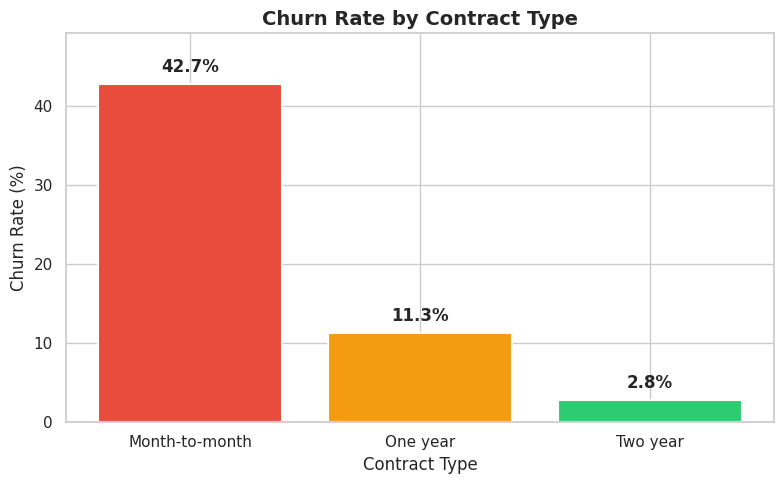

In [9]:
# Visualization 1: Churn rate by contract type
fig, ax = plt.subplots(figsize=(8, 5))
churn_by_contract = df.groupby('Contract')['Churn'].apply(lambda x: (x == 'Yes').mean() * 100).sort_values(ascending=False)
colors = ['#e74c3c', '#f39c12', '#2ecc71']
bars = ax.bar(churn_by_contract.index, churn_by_contract.values, color=colors, edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, churn_by_contract.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, f'{val:.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=12)
ax.set_title('Churn Rate by Contract Type', fontsize=14, fontweight='bold')
ax.set_ylabel('Churn Rate (%)', fontsize=12)
ax.set_xlabel('Contract Type', fontsize=12)
ax.set_ylim(0, max(churn_by_contract.values) * 1.15)
plt.tight_layout()
plt.show()

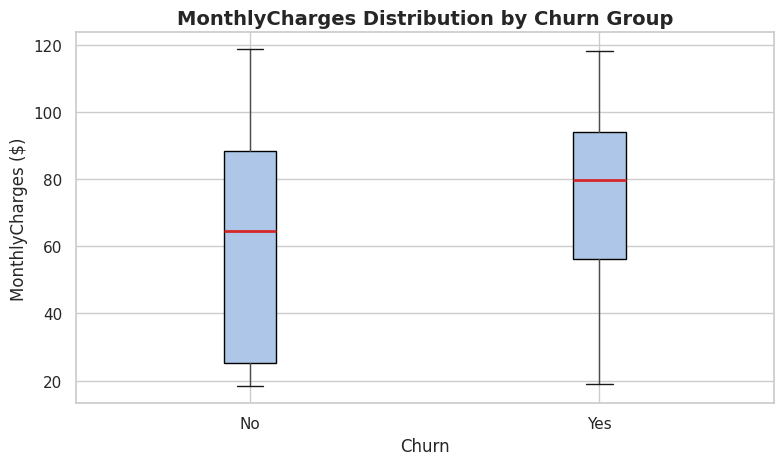

In [10]:
# Visualization 2: MonthlyCharges distribution by churn group
fig, ax = plt.subplots(figsize=(8, 5))
df.boxplot(column='MonthlyCharges', by='Churn', ax=ax, patch_artist=True,
           boxprops=dict(facecolor='#aec7e8'), medianprops=dict(color='#d62728', linewidth=2))
ax.set_title('MonthlyCharges Distribution by Churn Group', fontsize=14, fontweight='bold')
ax.set_xlabel('Churn', fontsize=12)
ax.set_ylabel('MonthlyCharges ($)', fontsize=12)
fig.suptitle('')
plt.tight_layout()
plt.show()

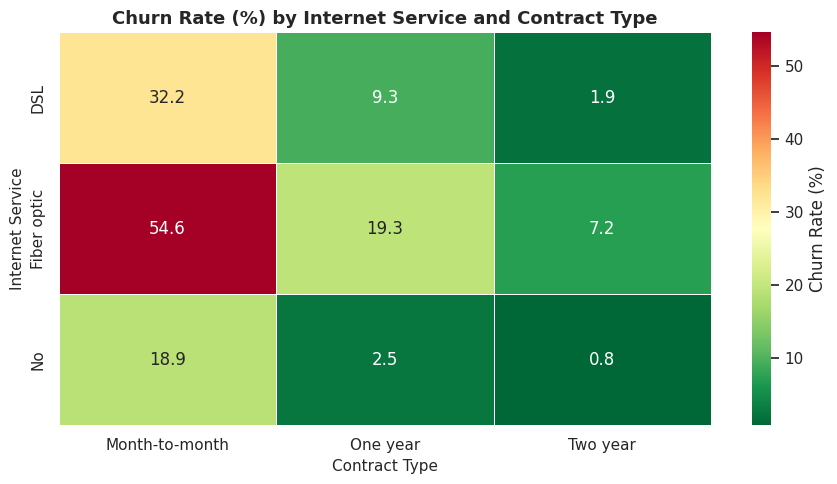

In [11]:
# Visualization 3: Churn rate heatmap by key segments
fig, ax = plt.subplots(figsize=(9, 5))
pivot = df.pivot_table(values='Churn', index='InternetService', columns='Contract',
                       aggfunc=lambda x: (x == 'Yes').mean() * 100)
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='RdYlGn_r', ax=ax, linewidths=0.5,
            cbar_kws={'label': 'Churn Rate (%)'})
ax.set_title('Churn Rate (%) by Internet Service and Contract Type', fontsize=13, fontweight='bold')
ax.set_ylabel('Internet Service', fontsize=11)
ax.set_xlabel('Contract Type', fontsize=11)
plt.tight_layout()
plt.show()